In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/marquis03/cats-and-dogs/val.csv
/kaggle/input/datasets/marquis03/cats-and-dogs/train.csv
/kaggle/input/datasets/marquis03/cats-and-dogs/val/classname.txt
/kaggle/input/datasets/marquis03/cats-and-dogs/val/dog/havanese_144_jpg.rf.d3e2e8cb9a7801e61894e372c4f1e1bb.jpg
/kaggle/input/datasets/marquis03/cats-and-dogs/val/dog/american_pit_bull_terrier_135_jpg.rf.f23ba7a8a1017fc71e62dcdeb3af9fa9.jpg
/kaggle/input/datasets/marquis03/cats-and-dogs/val/dog/great_pyrenees_190_jpg.rf.ebd07e7aae6a416425fa1f3c89872b61.jpg
/kaggle/input/datasets/marquis03/cats-and-dogs/val/dog/great_pyrenees_144_jpg.rf.d416d150a51cd8c6ae1489957c49e01b.jpg
/kaggle/input/datasets/marquis03/cats-and-dogs/val/dog/chihuahua_17_jpg.rf.d97aa2c7e61de5128686d82b87c95215.jpg
/kaggle/input/datasets/marquis03/cats-and-dogs/val/dog/english_cocker_spaniel_17_jpg.rf.f22312874dde3803847df16bcfe12f83.jpg
/kaggle/input/datasets/marquis03/cats-and-dogs/val/dog/american_bulldog_148_jpg.rf.f0a7b86489589aa05534a6f8cb

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow.keras.models import Sequential

2026-06-10 13:40:13.843319: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781098813.866901    1944 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781098813.874617    1944 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781098813.893889    1944 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781098813.893916    1944 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781098813.893919    1944 computation_placer.cc:177] computation placer alr

In [3]:
df = pd.read_csv('/kaggle/input/datasets/marquis03/cats-and-dogs/train.csv')
df.head()

,image:FILE,category
0,train/cat/Sphynx_159_jpg.rf.022528b23ac690c34a...,0
1,train/cat/Persian_139_jpg.rf.0e67f7e0a76dc49d0...,0
2,train/cat/Bengal_150_jpg.rf.05c93a40014062c5ae...,0
3,train/cat/Bombay_140_jpg.rf.15757f698af74453f3...,0
4,train/cat/Persian_128_jpg.rf.16da80c477d1ca2bc...,0


In [4]:
df.category.value_counts()

category
1    180
0     95
Name: count, dtype: int64

In [5]:
import os

os.listdir('/kaggle/input/datasets')

['marquis03']

In [6]:
example = '/kaggle/input/datasets/marquis03/cats-and-dogs/' + df.iloc[100]['image:FILE']
example


'/kaggle/input/datasets/marquis03/cats-and-dogs/train/dog/miniature_pinscher_108_jpg.rf.06b1992239cc6bee30c19531cb9db261.jpg'

In [7]:
!pip install pillow

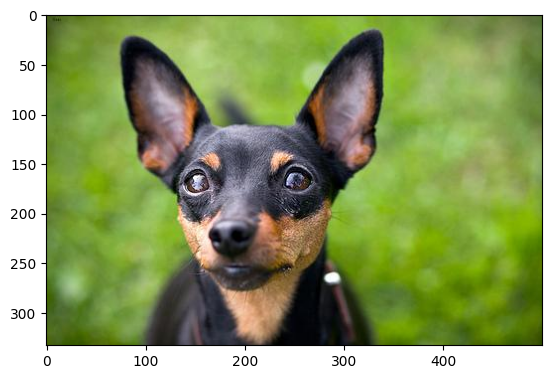

In [8]:
from PIL import Image

img = Image.open(example)

plt.imshow(img)

In [9]:
img.size

(500, 333)

In [10]:
np.array(img)

array([[[ 69,  92,  22],
        [ 70,  93,  23],
        [ 69,  92,  24],
        ...,
        [ 81, 105,  47],
        [ 79, 103,  45],
        [ 78, 102,  44]],

       [[ 67,  90,  20],
        [ 71,  94,  24],
        [ 71,  94,  26],
        ...,
        [ 83, 107,  49],
        [ 81, 105,  47],
        [ 80, 104,  46]],

       [[ 65,  88,  20],
        [ 71,  94,  26],
        [ 73,  95,  30],
        ...,
        [ 84, 109,  51],
        [ 83, 108,  50],
        [ 82, 107,  49]],

       ...,

       [[ 74, 101,   8],
        [ 74, 101,   8],
        [ 72, 101,   9],
        ...,
        [ 49,  77,   2],
        [ 47,  75,   0],
        [ 46,  74,   0]],

       [[ 73,  99,   8],
        [ 73,  99,   8],
        [ 71, 100,  10],
        ...,
        [ 49,  77,   2],
        [ 47,  75,   0],
        [ 46,  74,   0]],

       [[ 73,  99,  10],
        [ 72,  98,   9],
        [ 70,  99,   9],
        ...,
        [ 49,  77,   3],
        [ 46,  74,   0],
        [ 46,  74,   0]]

In [11]:
base_line = '/kaggle/input/datasets/marquis03/cats-and-dogs/'

df['base_line'] = base_line + df['image:FILE']
df.head()

,image:FILE,category,base_line
0,train/cat/Sphynx_159_jpg.rf.022528b23ac690c34a...,0,/kaggle/input/datasets/marquis03/cats-and-dogs...
1,train/cat/Persian_139_jpg.rf.0e67f7e0a76dc49d0...,0,/kaggle/input/datasets/marquis03/cats-and-dogs...
2,train/cat/Bengal_150_jpg.rf.05c93a40014062c5ae...,0,/kaggle/input/datasets/marquis03/cats-and-dogs...
3,train/cat/Bombay_140_jpg.rf.15757f698af74453f3...,0,/kaggle/input/datasets/marquis03/cats-and-dogs...
4,train/cat/Persian_128_jpg.rf.16da80c477d1ca2bc...,0,/kaggle/input/datasets/marquis03/cats-and-dogs...


In [12]:
df.drop(columns = ['image:FILE'], axis = 1,inplace = True)

In [13]:
df.sample(3)

,category,base_line
11,0,/kaggle/input/datasets/marquis03/cats-and-dogs...
84,0,/kaggle/input/datasets/marquis03/cats-and-dogs...
15,0,/kaggle/input/datasets/marquis03/cats-and-dogs...


In [14]:
df.shape

(275, 2)

In [15]:
images = []

for i in range(len(df)):
    img = Image.open(df.iloc[i]['base_line'])
    img = img.resize((224, 224))      # important for CNNs
    images.append(np.array(img))

X = np.array(images)

In [16]:
X.shape

(275, 224, 224, 3)

In [17]:
y = df['category']

In [18]:
# normal CNN

model = Sequential([
    layers.Rescaling(1./255,input_shape=(224,224,3)),
    layers.Conv2D(filters=32,kernel_size=(3,3),activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(filters=32,kernel_size=(3,3),activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(70,activation = 'relu'),
    layers.Dense(70,activation = 'sigmoid'),
    layers.Dense(1,activation = 'sigmoid')    
])

model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

model.fit(X,y,epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1781098822.328639    1944 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/10


I0000 00:00:1781098824.719452    2010 service.cc:152] XLA service 0x7ff898006750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781098824.719512    2010 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781098825.021231    2010 cuda_dnn.cc:529] Loaded cuDNN version 91002


7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6659 - loss: 0.6541

I0000 00:00:1781098827.472386    2010 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.6545 - loss: 0.6606
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6545 - loss: 0.6283
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6727 - loss: 0.6138
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6909 - loss: 0.5680
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7455 - loss: 0.5026
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8182 - loss: 0.4363
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9055 - loss: 0.3009
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9636 - loss: 0.1786
Epoch 9/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9891 - loss: 0.1082
Epoch 10/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9927 - loss: 0.0657


In [19]:
df1 = pd.read_csv('/kaggle/input/datasets/marquis03/cats-and-dogs/val.csv')

base_line = '/kaggle/input/datasets/marquis03/cats-and-dogs/'

df1['base_line'] = base_line + df1['image:FILE']

images_val = []

for i in range(len(df1)):
    img = Image.open(df1.iloc[i]['base_line'])
    img = img.resize((224, 224))      # important for CNNs
    images_val.append(np.array(img))

X_val = np.array(images_val)
y_val = df1.category

model.evaluate(X_val,y_val)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 330ms/step - accuracy: 0.5714 - loss: 0.9754


[0.9754116535186768, 0.5714285969734192]

$TensorFlow Hub$ is a repository of pre-trained TensorFlow models.

This tutorial demonstrates how to:

1. Use models from TensorFlow Hub with tf.keras.
2. Use an image classification model from TensorFlow Hub.
3. Do simple transfer learning to fine-tune a model for your own image classes



In [20]:
import tensorflow_hub as hub
IMAGE_SHAPE = (224, 224)

base_model = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top = False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalMaxPooling2D(),
    layers.Dense(1,activation = 'sigmoid')
])

model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

model.fit(X,y,epochs=10)
model.evaluate(X_val,y_val)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 757ms/step - accuracy: 0.5709 - loss: 1.2406
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5600 - loss: 0.8938
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6364 - loss: 0.8347
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7055 - loss: 0.6944
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6800 - loss: 0.6400
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7636 - loss: 0.5723
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7236 - loss: 0.5461
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7418 - loss: 0.5250
Epoch 9/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7564 - loss: 0.4630
Epoch 10/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7564 - loss: 0.4714
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.6429 - loss: 0.7270


[0.7270163893699646, 0.6428571343421936]

without transfer learning
train accuracy = 0.99
test accuracy = 0.57 (overfitting)

with transfer learning
train accuracy = 0.76
test accuracy = 0.64 (good fit)
